In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
delivery_count = (
    df["Has Online delivery"]
    .value_counts()
    .reset_index()
)

delivery_count.columns = ["Online Delivery", "Restaurant Count"]

delivery_count

,Online Delivery,Restaurant Count
0,No,7100
1,Yes,2451


In [4]:
delivery_count["Percentage (%)"] = (
    delivery_count["Restaurant Count"] / len(df)
) * 100

delivery_count["Percentage (%)"] = delivery_count["Percentage (%)"].round(2)

delivery_count

,Online Delivery,Restaurant Count,Percentage (%)
0,No,7100,74.34
1,Yes,2451,25.66


In [5]:
ratings = (
    df.groupby("Has Online delivery")["Aggregate rating"]
      .mean()
      .reset_index()
)

ratings.columns = ["Online Delivery", "Average Rating"]

ratings

,Online Delivery,Average Rating
0,No,2.465296
1,Yes,3.248837


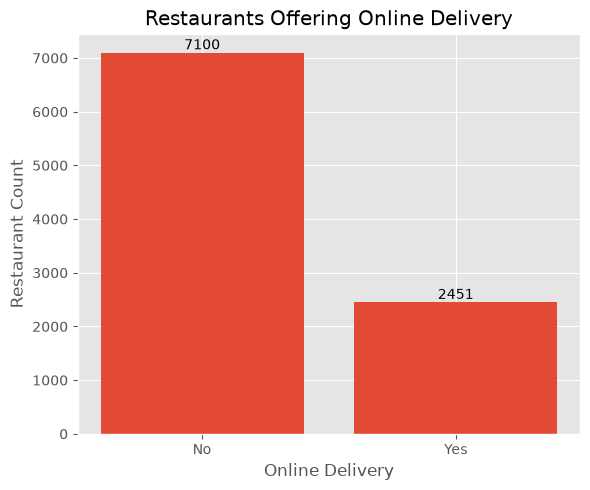

In [6]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    delivery_count["Online Delivery"],
    delivery_count["Restaurant Count"]
)

plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Restaurant Count")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

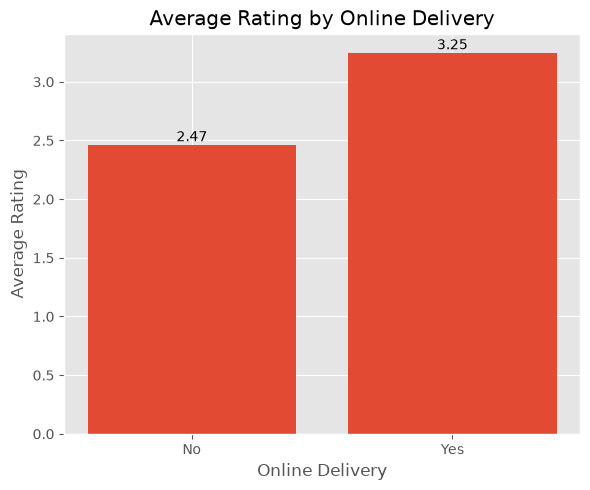

In [7]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    ratings["Online Delivery"],
    ratings["Average Rating"]
)

plt.title("Average Rating by Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

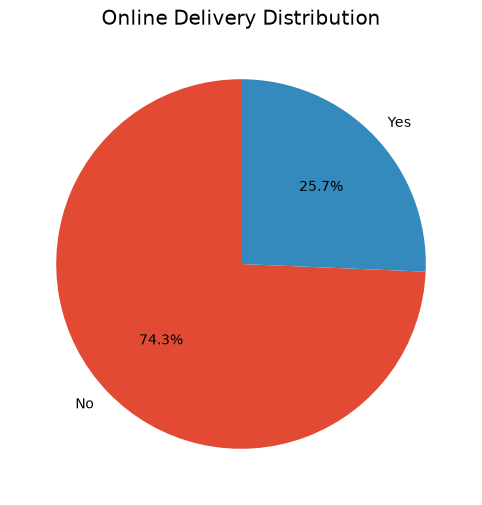

In [8]:
plt.figure(figsize=(6,6))

plt.pie(
    delivery_count["Restaurant Count"],
    labels=delivery_count["Online Delivery"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Online Delivery Distribution")

plt.show()

In [9]:
summary = delivery_count.merge(
    ratings,
    on="Online Delivery"
)

summary

,Online Delivery,Restaurant Count,Percentage (%),Average Rating
0,No,7100,74.34,2.465296
1,Yes,2451,25.66,3.248837


# Observations

- Calculated the percentage of restaurants offering online delivery.
- Compared average ratings of restaurants with and without online delivery.
- Visualized restaurant counts using a bar chart.
- Compared average ratings using a second bar chart.
- Displayed the distribution using a pie chart.
- The analysis helps understand whether online delivery is associated with higher customer ratings.